In [9]:
import pandas as pd
import matplotlib.pyplot as plt 

def load_data():
    data=pd.read_excel('/Users/apple/QuantNew/Data/Sbi.xlsx')
    data = data.sort_values("DATE")

    data["Date"]=pd.to_datetime(data["DATE"])
    data["Close"]=pd.to_numeric(data["CLOSE"],errors="coerce")



    data["SMA_20"]=data["Close"].rolling(window=20).mean()
    data["SMA_50"]=data["Close"].rolling(window=50).mean()
    data["SMA_200"]=data["Close"].rolling(window=200).mean()

    data["EMA_20"] = data["Close"].ewm(alpha= 0.5, adjust=False).mean()
    data["EMA_50"] = data["Close"].ewm(span=50, adjust=False).mean()
    data["EMA_200"] = data["Close"].ewm(span=200, adjust=False).mean()    
    return data[["Date", "Close", "EMA_20", "EMA_50", "EMA_200"]]


In [10]:
import data

df=data.load_data()


def Crossover(df):
    df["EMA_diff"] = df["EMA_20"] - df["EMA_200"]
    # Diff shifts from negative to positive---Buy
    # Diff shifts from positive to negative---sell
    df["Buy"] = (
        (df["EMA_diff"].shift(1) < 0)&
        (df["EMA_diff"] > 0)
    )

    df["Sell"] = (
        (df["EMA_diff"].shift(1) > 0)&
        (df["EMA_diff"] < 0)
    )

    df["Position"] = 0
    position = 0

    for i in range(len(df)):

        if df["Buy"].iloc[i] and position == 0:
            position = 1

        elif df["Sell"].iloc[i] and position == 1:
            position = 0
    
        df.iloc[i, df.columns.get_loc("Position")] = position

    return df


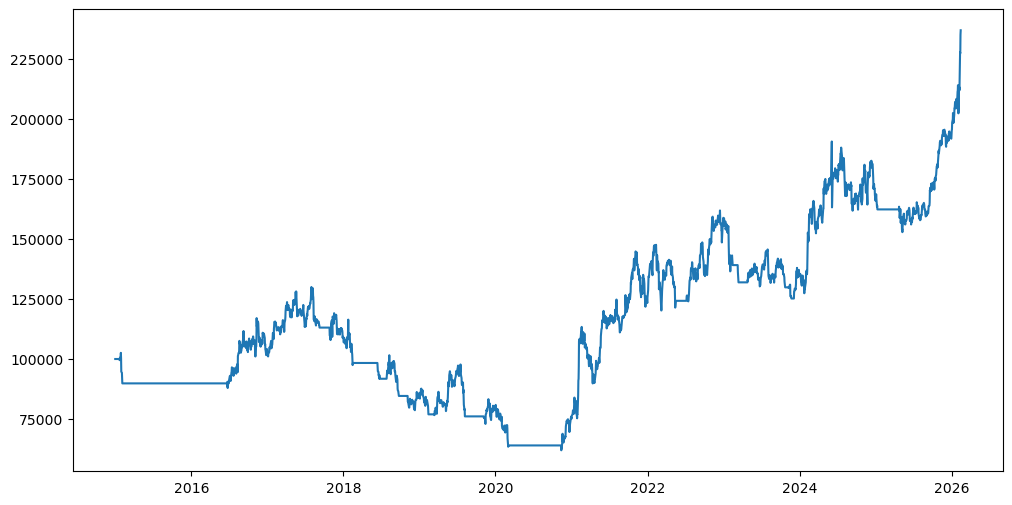

In [11]:
import data
import statergy
import matplotlib.pyplot as plt

# Load data
df = data.load_data()

# Generate signals
df = statergy.Crossover(df)

initial_capital = 100000

# Daily returns
df["Return"] = df["Close"].pct_change()

# Strategy returns
df["Strategy_Return"] = df["Position"] * df["Return"]

df["Trade"] = df["Position"].diff()

# Equity curve (compounded)
#df["Equity"] = initial_capital * (1 + df["Strategy_Return"]).cumprod()

cash = initial_capital
shares = 0
equity_list = []

for i in range(len(df)):

    if df["Trade"].iloc[i] == 1:  # Buy
        shares = cash / df["Close"].iloc[i]
        cash = 0

    elif df["Trade"].iloc[i] == -1:  # Sell
        cash = shares * df["Close"].iloc[i]
        shares = 0

    equity = cash + shares * df["Close"].iloc[i]
    equity_list.append(equity)

df["Equity"] = equity_list



# Plot equity curve
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Equity"])
plt.show()